Convoluted audio saved as 'output_convoluted.wav'.


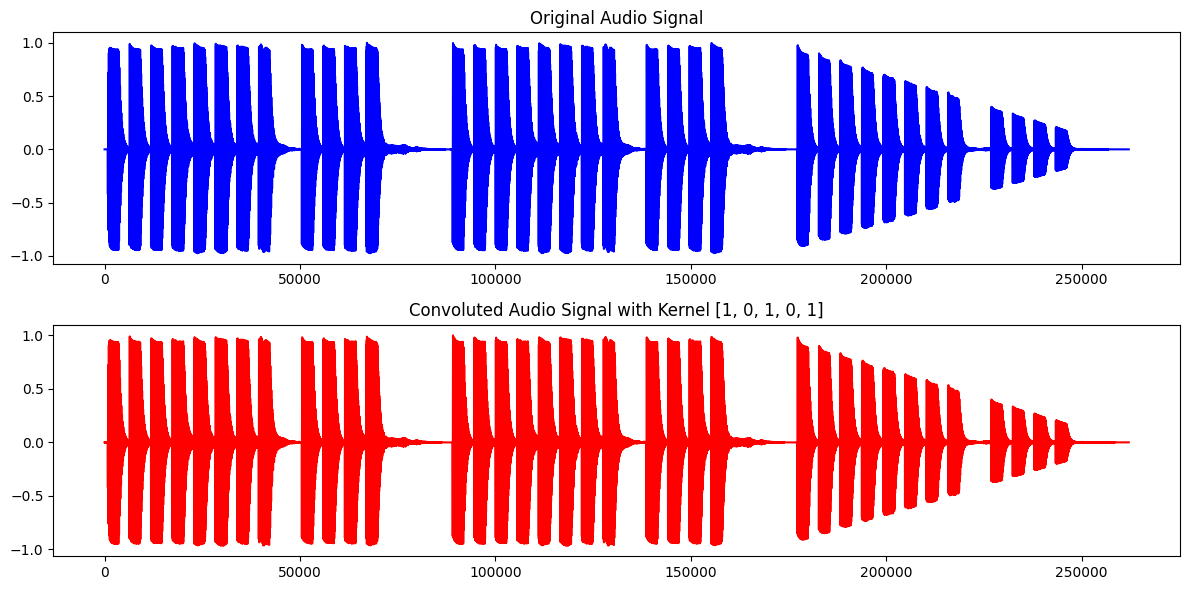

In [ ]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
audio = AudioSegment.from_mp3("audio_file.mp3")
audio = audio.set_channels(1)
samples = np.array(audio.get_array_of_samples()).astype(np.float32)
kernel = np.array([1, 0, 1, 0, 1], dtype=np.float32)
convoluted = convolve(samples, kernel, mode='same')
convoluted = convoluted / np.max(np.abs(convoluted))
convoluted_int16 = (convoluted * 32767).astype(np.int16)
convoluted_audio = AudioSegment(
    convoluted_int16.tobytes(),
    frame_rate=audio.frame_rate,
    sample_width=2,
    channels=1
)
convoluted_audio.export("output_convoluted.wav", format="wav")
print("Convoluted audio saved as 'output_convoluted.wav'.")
samples_norm = samples / np.max(np.abs(samples))
convoluted_norm = convoluted
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(samples_norm, color='blue')
plt.title("Original Audio Signal")
plt.subplot(2, 1, 2)
plt.plot(convoluted_norm, color='red')
plt.title("Convoluted Audio Signal with Kernel [1, 0, 1, 0, 1]")
plt.tight_layout()
plt.show()